# CAE v2: Post-Processing & Physical Evaluation

**Description:** 

Evaluates a trained Convolutional Autoencoder (CAE) model on the cylinder wake dataset.

Analyzes reconstruction topology, pixel-wise energy loss, and the geometry of the non-linear latent space.

**Author:** Marcel Wilanowicz

**Date:** 2026-06-09

## 1. Setup & Environment

Libraries, models, and directory setting.

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
from sklearn.manifold import TSNE
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
from IPython.display import display, HTML

In [28]:
sys.path.append('../src')

In [29]:
from models.cae_v2 import CAE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
DATA_PATH = "../data/processed/cylinder_nektar_wake_norm.npy"
data = np.load(DATA_PATH)

In [31]:
CAE_MODEL_PATH = "../checkpoints/cae_v2_best.pth"
CAE_HISTORY_PATH = "../history/cae_v2_history.pth"

In [32]:
cae_model = CAE().to(device)
cae_model.load_state_dict(torch.load(CAE_MODEL_PATH, map_location=device))
cae_model.eval()

model_preview = f"<pre style='font-family: monospace; line-height: 1.4;'>{cae_model}</pre>"
display(HTML(model_preview))

In [58]:
def count_trainable_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

with torch.no_grad():
    dummy_input = torch.zeros(1, 3, 128, 256).to(device)
    latent_dimension = cae_model.encoder(dummy_input).shape[1]

print(f"CAE v2:")
print("-"*60)
print(f"Latent Dimension: {latent_dimension}")
print(f"Trainable parameters: {count_trainable_parameters(cae_model)}")
print("-"*60)

CAE v2:
------------------------------------------------------------
Latent Dimension: 16
Trainable parameters: 182515
------------------------------------------------------------


## 2. Model's MSE Score

Loading pre-computed quantitative metrics (MSE) for the training and validation datasets ($u$, $v$, $p$).

In [33]:
cae_history = torch.load(CAE_HISTORY_PATH)

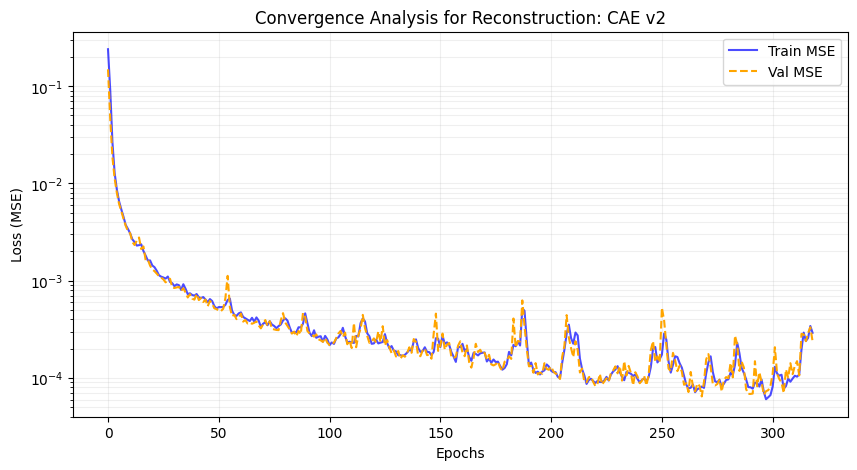

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(cae_history['train_loss'], label='Train MSE', color='blue', alpha=0.7)
plt.plot(cae_history['val_loss'], label='Val MSE', color='orange', linestyle='--')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Convergence Analysis for Reconstruction: CAE v2')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

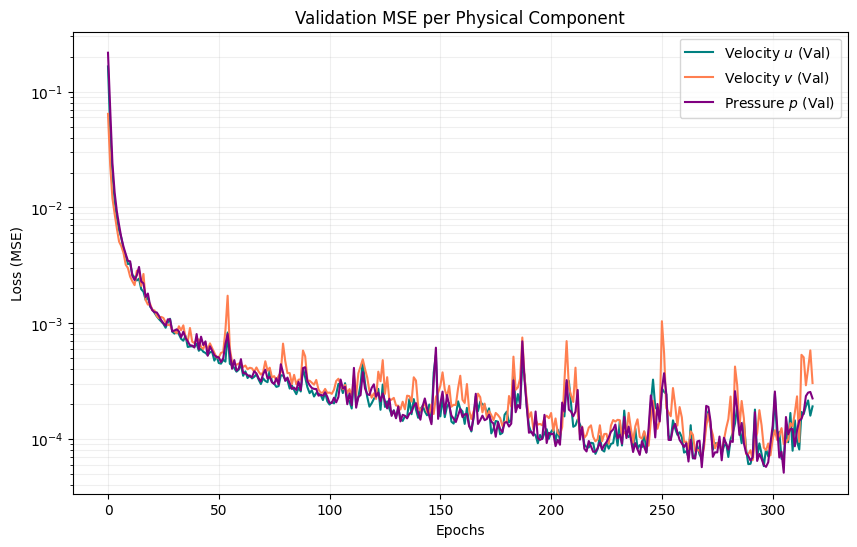

In [35]:
plt.figure(figsize=(10, 6))

# Plotting each channel from the history dictionary
plt.plot(cae_history['val_loss_u'], label='Velocity $u$ (Val)', color='teal')
plt.plot(cae_history['val_loss_v'], label='Velocity $v$ (Val)', color='coral')
plt.plot(cae_history['val_loss_p'], label='Pressure $p$ (Val)', color='purple')

plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Validation MSE per Physical Component')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [36]:
cae_best_val_loss = min(cae_history['val_loss'])
best_idx = cae_history['val_loss'].index(cae_best_val_loss)
cae_best_train_loss = cae_history['train_loss'][best_idx]


# Extracting channel-specific values at that same index
cae_best_u_val_loss = cae_history['val_loss_u'][best_idx]
cae_best_v_val_loss = cae_history['val_loss_v'][best_idx]
cae_best_p_val_loss = cae_history['val_loss_p'][best_idx]

best_epoch_rec = best_idx + 1

print("\n" + "="*60)
print(f"{'CAE v2 ASSESSMENT':^60}")
print("="*60)
print(f"{'Component / Metric':<35} | {'MSE Value':<15}")
print("-"*60)
print(f"{'Train MSE (Overall at Best Epoch)':<35} | {cae_best_train_loss:.6f}")
print(f"{'Val MSE (Overall - Best)':<35} | {cae_best_val_loss:.6f}")
print("-"*60)
print(f"{'Val MSE - u (horizontal vel.)':<35} | {cae_best_u_val_loss:.6f}")
print(f"{'Val MSE - v (vertical vel.)':<35} | {cae_best_v_val_loss:.6f}")
print(f"{'Val MSE - p (pressure)':<35} | {cae_best_p_val_loss:.6f}")
print("-"*60)
print(f"{'Early Stopping Optimal Epoch':<35} | {best_epoch_rec}")
print("="*60 + "\n")


                     CAE v2 ASSESSMENT                      
Component / Metric                  | MSE Value      
------------------------------------------------------------
Train MSE (Overall at Best Epoch)   | 0.000082
Val MSE (Overall - Best)            | 0.000065
------------------------------------------------------------
Val MSE - u (horizontal vel.)       | 0.000068
Val MSE - v (vertical vel.)         | 0.000069
Val MSE - p (pressure)              | 0.000057
------------------------------------------------------------
Early Stopping Optimal Epoch        | 269



## 3. Latent Space & Topological Analysis

In [37]:
# Data slicing and preperation

# Full time-series sequence
x_all = data
# Convert whole dataset to PyTorch tensor for CAE encoder
x_all_tensor = torch.from_numpy(x_all).float().to(device) # (200, 3, 128, 256)

# Project full dataset onto the model's latent space
with torch.no_grad():
    latent_all = cae_model.encoder(x_all_tensor).cpu().numpy() # (200, 3, 128, 256) -> (200, 8)

print(f"x_all_tensor: {x_all_tensor.shape}")
print(f"latent_all: {latent_all.shape}\n")

x_all_tensor: torch.Size([200, 3, 128, 256])
latent_all: (200, 16)



### 3.1. Latent Trajectory Projections (Linear Mapping / PCA)

In [38]:
# PCA 2D Projections (Linear reduction of latent space to verify limit cycle)

# Project 8D latent space onto 2 principal components for full dataset
pca_all_2d_handler = PCA(n_components=2)
latent_all_pca_2d = pca_all_2d_handler.fit_transform(latent_all) # (200, 8) -> (200, 2)

print(f"pca_all_2d_handler: {pca_all_2d_handler}")
print(f"latent_all_pca_2d: {latent_all_pca_2d.shape}\n")

pca_all_2d_handler: PCA(n_components=2)
latent_all_pca_2d: (200, 2)



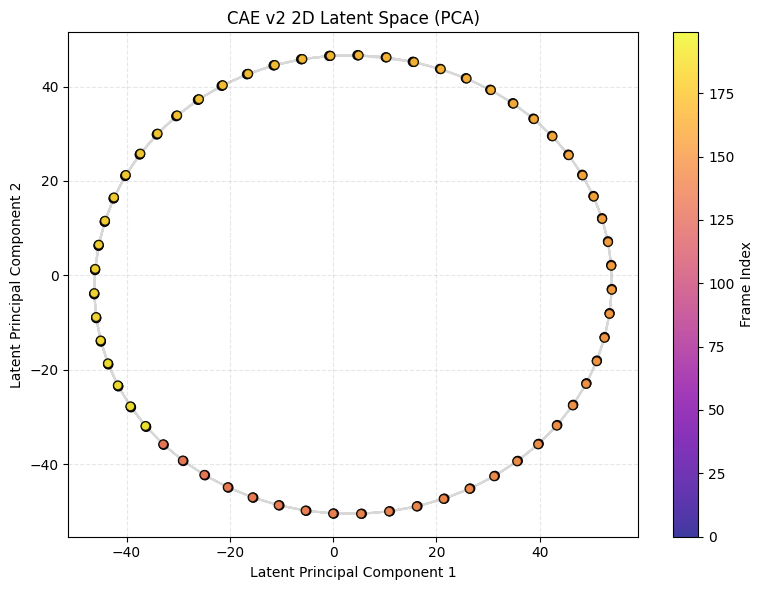

In [39]:
# 1. Plot the continuous trajectory line
plt.figure(figsize=(8, 6), dpi=100)
plt.plot(
    latent_all_pca_2d[:, 0],
    latent_all_pca_2d[:, 1],
    color="gray",
    linestyle="-",
    alpha=0.3,
    zorder=1,
)

# 2. Scatter plot with chronological sequential colormap
scatter_all_pca = plt.scatter(
    latent_all_pca_2d[:, 0],
    latent_all_pca_2d[:, 1],
    c=range(len(latent_all_pca_2d)),
    cmap="plasma",
    edgecolor="k",
    s=40,
    alpha=0.8,
    zorder=2,
)

plt.title("CAE v2 2D Latent Space (PCA)")
plt.xlabel("Latent Principal Component 1")
plt.ylabel("Latent Principal Component 2")
cbar = plt.colorbar(scatter_all_pca)
cbar.set_label("Frame Index")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# PCA 3D Projections (Linear reduction of latent space for 3D visualization)

# Project 8D latent space onto 3 principal components for 3D visualization
pca_3d_handler = PCA(n_components=3)
latent_all_pca_3d = pca_3d_handler.fit_transform(latent_all) # (200, 8) -> (200, 3)

df_latent_all_pca_3d = pd.DataFrame( # (200, 3) + 1 time column -> (200, 4)
    {
        "PC 1": latent_all_pca_3d[:, 0], # Latent component 1 (X-axis)
        "PC 2": latent_all_pca_3d[:, 1], # Latent component 2 (Y-axis)
        "PC 3": latent_all_pca_3d[:, 2], # Latent component 3 (Z-axis)
        "Frame Index": range(len(latent_all_pca_3d)), # Temporal index column
    }
)

print(f"latent_val_pca_3d: {latent_all_pca_3d.shape}")
print(f"latent_all_pca_3d: {df_latent_all_pca_3d.shape}\n")

latent_val_pca_3d: (200, 3)
latent_all_pca_3d: (200, 4)



In [41]:
# Generate interactive 3D scatter plot with a continuous line
fig = px.scatter_3d(
    df_latent_all_pca_3d,
    x="PC 1",
    y="PC 2",
    z="PC 3",
    color="Frame Index",
    color_continuous_scale="plasma",
    title="CAE v2 3D Latent Space (PCA)",
)

# Connect the scatter points with a continuous trajectory line
fig.update_traces(mode="markers+lines", marker=dict(size=4, opacity=0.8))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

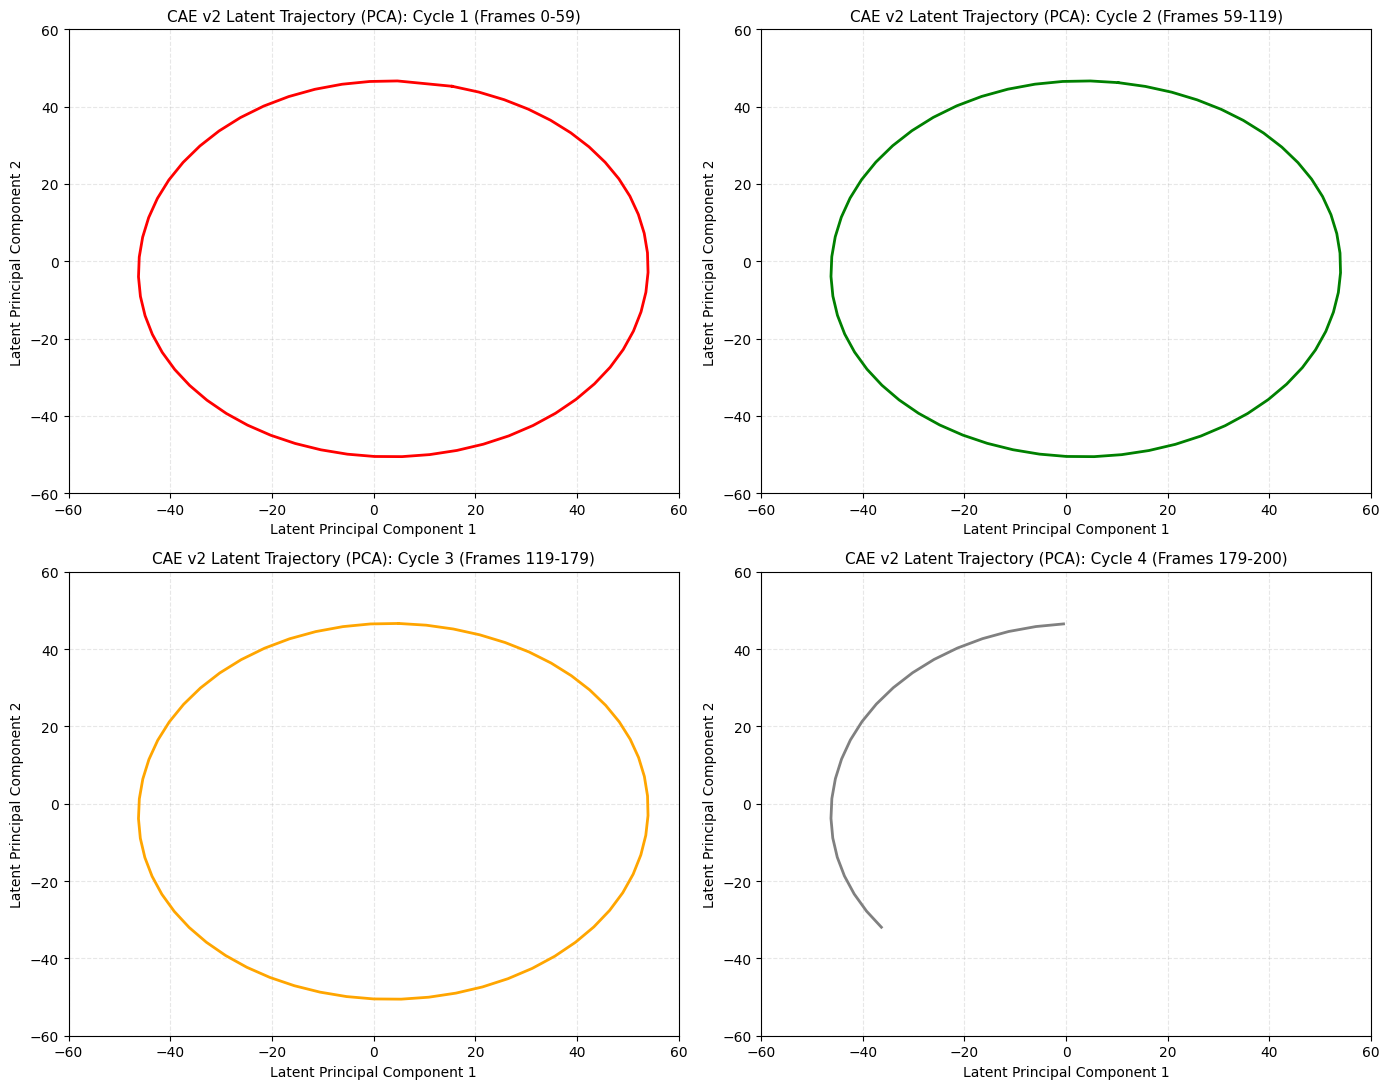

In [42]:
# PCA Cycles

fig, axs = plt.subplots(2, 2, figsize=(14, 11), dpi=100)

cycles_data = [
    (slice(0, 59), "Cycle 1 (Frames 0-59)", "red"),
    (slice(59, 119), "Cycle 2 (Frames 59-119)", "green"),
    (slice(119, 179), "Cycle 3 (Frames 119-179)", "orange"),
    (slice(179, 200), "Cycle 4 (Frames 179-200)", "gray"),
]

for ax, (frame_slice, title, color) in zip(axs.flat, cycles_data):
    ax.plot(
        latent_all_pca_2d[frame_slice, 0],
        latent_all_pca_2d[frame_slice, 1],
        color=color,
        linestyle="-",
        linewidth=2,
    )
    ax.set_xlim([-60, 60])
    ax.set_ylim([-60, 60])
    ax.set_title(f"CAE v2 Latent Trajectory (PCA): {title}", fontsize=11)
    ax.set_xlabel("Latent Principal Component 1")
    ax.set_ylabel("Latent Principal Component 2")
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2. t-SNE Projections (Non-linear Neighborhood Mapping)

In [43]:
# t-SNE 2D Projections (Non-linear reduction for neighborhood structure)

# Fit t-SNE for full dataset (higher perplexity for global structure)
tsne_all_handler = TSNE(n_components=2, perplexity=30, random_state=42)
latent_all_tsne_2d = tsne_all_handler.fit_transform(latent_all) # (200, 8) 

print(f"latent_all_tsne_2d:  {latent_all_tsne_2d.shape}")

latent_all_tsne_2d:  (200, 2)


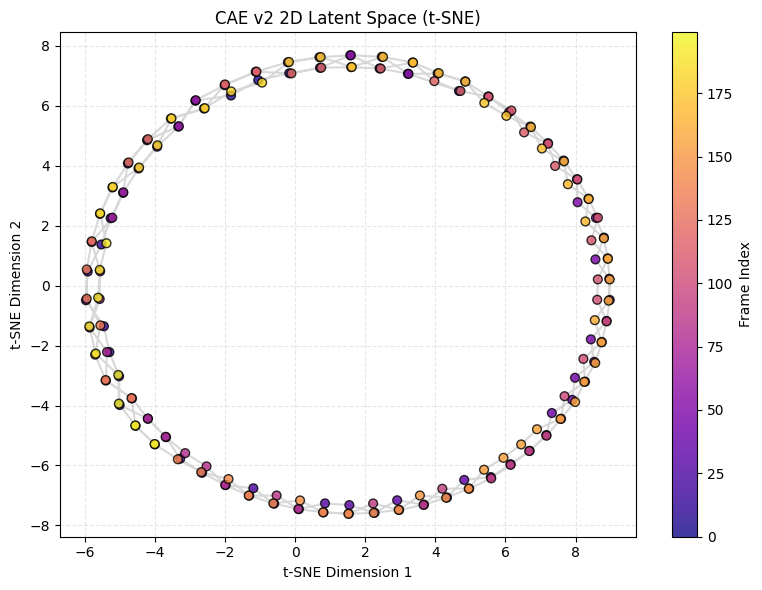

In [44]:
# Plot continuous trajectory line
plt.figure(figsize=(8, 6), dpi=100)
plt.plot(
    latent_all_tsne_2d[:, 0],
    latent_all_tsne_2d[:, 1],
    color="gray",
    linestyle="-",
    alpha=0.3,
    zorder=1,
)

# Scatter plot with chronological sequential colormap
scatter_all_tsne = plt.scatter(
    latent_all_tsne_2d[:, 0],
    latent_all_tsne_2d[:, 1],
    c=range(len(latent_all_tsne_2d)),
    cmap="plasma",
    edgecolor="k",
    s=40,
    alpha=0.8,
    zorder=2,
)

plt.title("CAE v2 2D Latent Space (t-SNE)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
cbar = plt.colorbar(scatter_all_tsne)
cbar.set_label("Frame Index")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
# t-SNE 3D Projections (Non-linear reduction for neighborhood structure)

# Fit t-SNE for full dataset (higher perplexity for global structure)
tsne_all_3d_handler = TSNE(n_components=3, perplexity=50, random_state=42)
latent_all_tsne_3d = tsne_all_3d_handler.fit_transform(latent_all) # (200, 8) -> (200, 3)

df_latent_all_tsne_3d = pd.DataFrame( # (200, 3) + 1 time column -> (200, 4)
    {
        "t-SNE 1": latent_all_tsne_3d[:, 0], # t-SNE component 1 (X-axis)
        "t-SNE 2": latent_all_tsne_3d[:, 1], # t-SNE component 2 (Y-axis)
        "t-SNE 3": latent_all_tsne_3d[:, 2], # t-SNE component 3 (Z-axis)
        "Frame": range(len(latent_all_tsne_3d)), # Temporal index column
    }
)

print(f"latent_all_tsne_3d: {latent_all_tsne_3d.shape}")
print(f"df_latent_all_tsne_3d rows/cols: {df_latent_all_tsne_3d.shape}")

latent_all_tsne_3d: (200, 3)
df_latent_all_tsne_3d rows/cols: (200, 4)


In [46]:
# Create interactive 3D scatter plot for t-SNE with continuous trajectory line
fig_tsne_3d = px.scatter_3d(
    df_latent_all_tsne_3d,
    x="t-SNE 1",
    y="t-SNE 2",
    z="t-SNE 3",
    color="Frame",
    color_continuous_scale="plasma",  # Change to "plasma" in CAE notebook
    title="CAE v2 3D Latent Space (t-SNE)",
    labels={"Frame": "Frame Index"},
)

# Format marker styling and enable chronological line drawing
fig_tsne_3d.update_traces(
    mode="markers+lines", # Enables both dots and the trajectory line
    marker=dict(size=5, opacity=0.8, line=dict(width=1, color="black")),
    line=dict(width=2) # Adjust thickness of the trajectory line
)
fig_tsne_3d.update_layout(margin=dict(l=0, r=0, b=0, t=40), scene=dict(aspectmode='data'))
fig_tsne_3d.show()

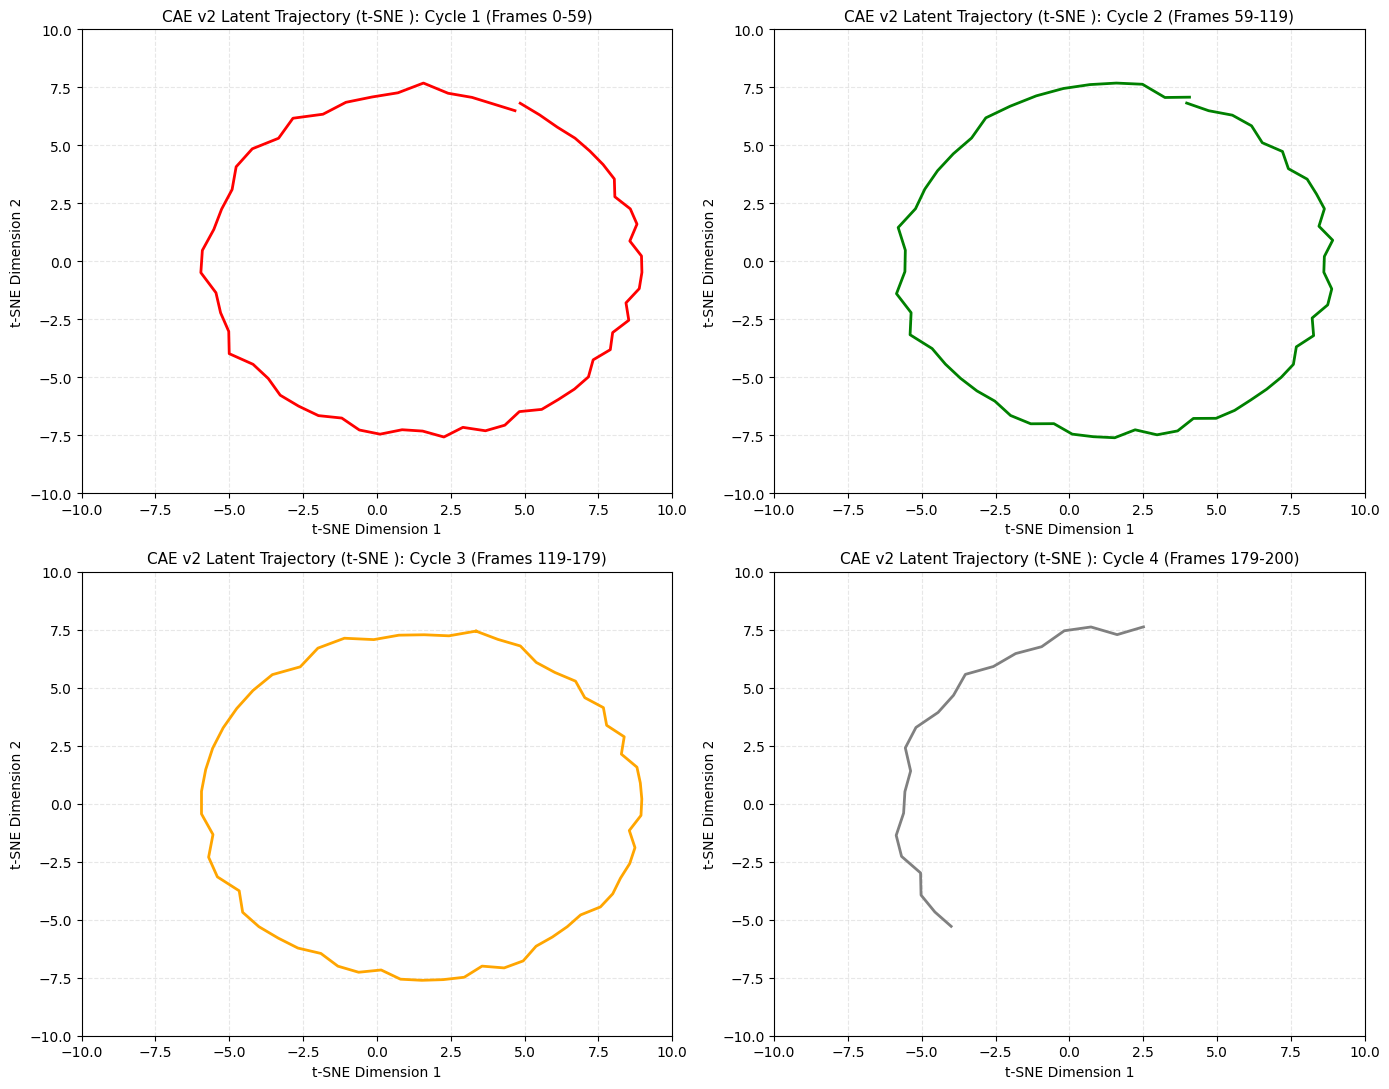

In [47]:
# t-SNE Cycles

fig, axs = plt.subplots(2, 2, figsize=(14, 11), dpi=100)

cycles_data = [
    (slice(0, 59), "Cycle 1 (Frames 0-59)", "red"),
    (slice(59, 119), "Cycle 2 (Frames 59-119)", "green"),
    (slice(119, 179), "Cycle 3 (Frames 119-179)", "orange"),
    (slice(179, 200), "Cycle 4 (Frames 179-200)", "gray"),
]

for ax, (frame_slice, title, color) in zip(axs.flat, cycles_data):
    ax.plot(
        latent_all_tsne_2d[frame_slice, 0],
        latent_all_tsne_2d[frame_slice, 1],
        color=color,
        linestyle="-",
        linewidth=2,
    )
    
    ax.set_xlim([-10, 10])
    ax.set_ylim([-10, 10])
    
    ax.set_title(f"CAE v2 Latent Trajectory (t-SNE ): {title}", fontsize=11)
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3. Phase Verification & Spatial Consistency

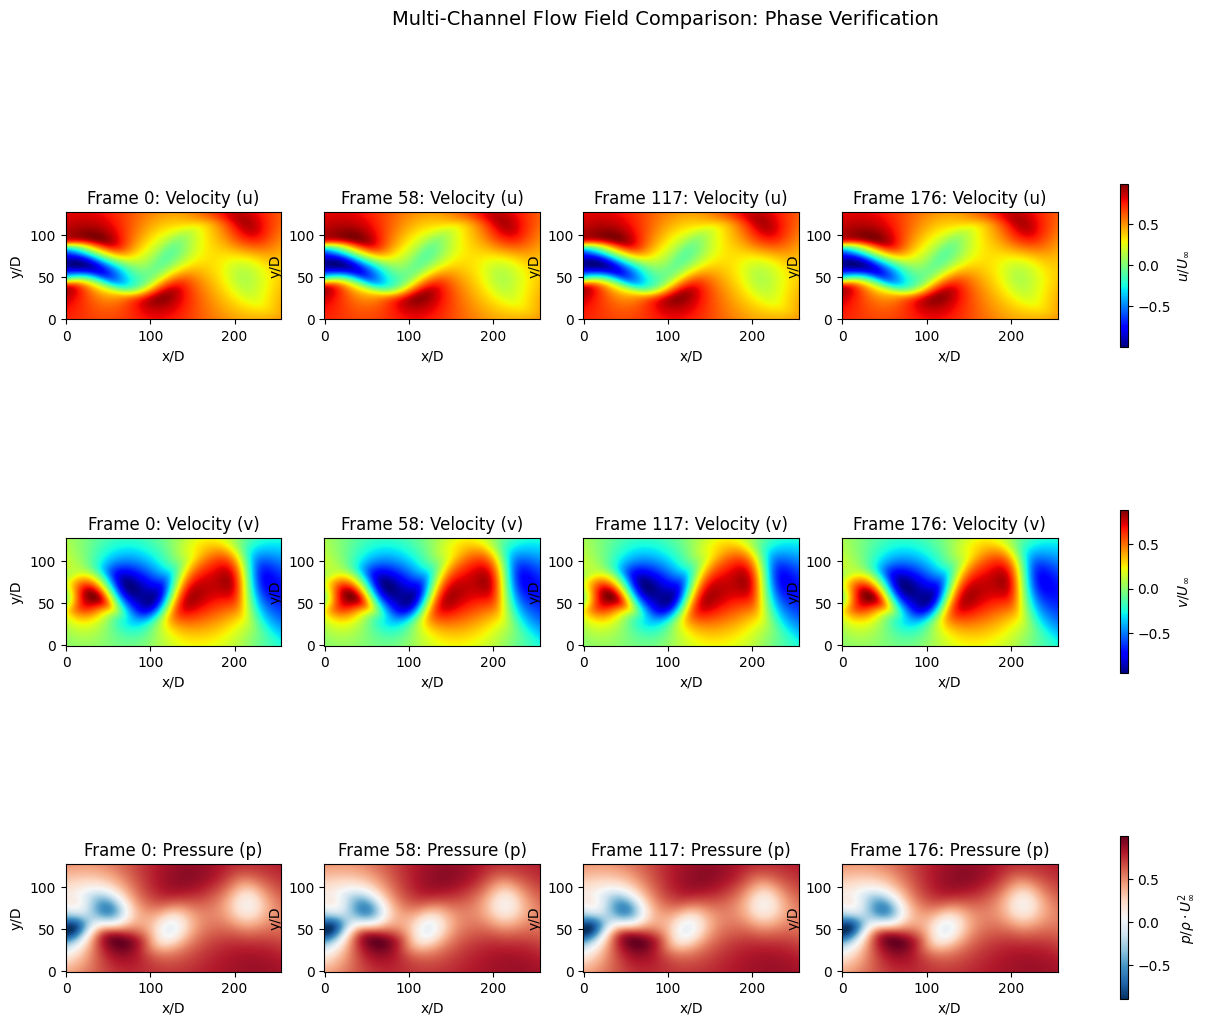

In [48]:
# Multi-Channel Phase Verification

target_frames = [0, 58, 117, 176]
channels = [
    "Velocity (u)",
    "Velocity (v)",
    "Pressure (p)",
]
cmaps = ["jet", "jet", "RdBu_r"]
units = ["$u / U_{\infty}$", "$v / U_{\infty}$", r"$p / \rho \cdot U_{\infty}^2$"]

# 2. Create subplot grid: 3 rows (channels) x 4 columns (frames)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for ch in range(3):
    # Determine global min/max for the row to keep colorbar scale consistent
    row_data = x_all[target_frames, ch, :, :]
    v_min, v_max = row_data.min(), row_data.max()

    for i, frame_idx in enumerate(target_frames):
        # Extract specific channel and frame from tensor shape (N, C, H, W)
        frame_data = x_all[frame_idx, ch, :, :]  # (128, 256)

        # Display the flow field with fixed row-wise scale
        im = axes[ch, i].imshow(
            frame_data, cmap=cmaps[ch], origin="lower", vmin=v_min, vmax=v_max
        )

        # Set labels and titles per subplot
        axes[ch, i].set_title(f"Frame {frame_idx}: {channels[ch]}")
        axes[ch, i].set_xlabel("x/D")
        axes[ch, i].set_ylabel("y/D")

    # Add one shared colorbar per row (channel)
    fig.colorbar(im, ax=axes[ch, :].tolist(), label=units[ch], shrink=0.6)

plt.suptitle("Multi-Channel Flow Field Comparison: Phase Verification", fontsize=14)
plt.show()

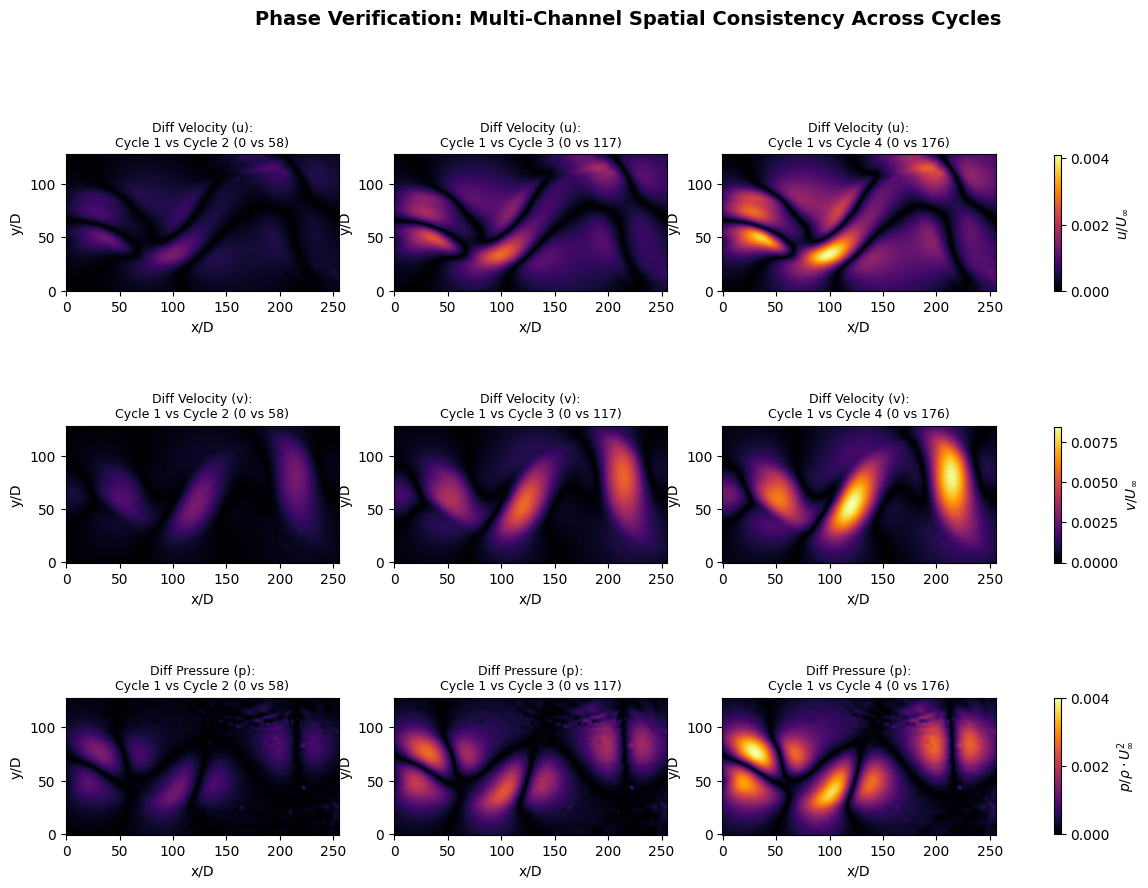

In [49]:
# Spatial Consistency Across Cycles

target_frames = [0, 58, 117, 176]
comparison_frames = [58, 117, 176]
channels = [
    "Velocity (u)",
    "Velocity (v)",
    "Pressure (p)",
]
units = ["$u / U_{\infty}$", "$v / U_{\infty}$", r"$p / \rho \cdot U_{\infty}^2$"]

# Create subplot grid: 3 rows (channels) x 3 columns (comparisons)
fig, axes = plt.subplots(3, 3, figsize=(15, 10), dpi=100)

for ch in range(3):
    # Initial phase
    base_frame = x_all[0, ch, :, :]
    
    # Determine the maximum difference in the row to keep colorbar scale consistent
    row_diffs = [np.abs(base_frame - x_all[f, ch, :, :]) for f in comparison_frames]
    v_max = max([d.max() for d in row_diffs])
    if v_max == 0: 
        v_max = 1e-5

    for i, frame_idx in enumerate(comparison_frames):
        frame_data = x_all[frame_idx, ch, :, :]
        
        # Absolute difference between the first cycle and subsequent cycles
        diff = np.abs(base_frame - frame_data)
        
        # vmin=0, because the absolute error will not be less than zero
        im = axes[ch, i].imshow(diff, cmap="inferno", origin="lower", vmin=0, vmax=v_max)
        
        if ch == 0:
            axes[ch, i].set_title(f"Diff: Cycle 1 vs Cycle {i+2}\n(Frame 0 vs {frame_idx})", fontsize=10)

        axes[ch, i].set_title(
            f"Diff {channels[ch]}:\nCycle 1 vs Cycle {i+2} (0 vs {frame_idx})", 
            fontsize=9
        )    
        axes[ch, i].set_xlabel("x/D")
        axes[ch, i].set_ylabel("y/D")

    fig.colorbar(im, ax=axes[ch, :].tolist(), label=units[ch], shrink=0.6)

plt.suptitle("Phase Verification: Multi-Channel Spatial Consistency Across Cycles", fontsize=14, fontweight="bold")
plt.show()

## 4. Original VS Reconstructed Absolute Error (Pixel-Wise)

Side-by-side snapshots and absolute error maps for $u$, $v$, $p$, and $|U|$.

In [50]:
idx = 190 # Frame nr 190 (not seen by model)
frame = torch.from_numpy(data[idx]).float().to(device) # One frame of dimension: C x H x W
test_input = frame.unsqueeze(0) # Results in: 1 x C x H x W (model needs B x C x H x W)

with torch.no_grad():
    test_output = cae_model(test_input) # Same as input: 1 x C x H x W

original = test_input.squeeze(0).cpu().numpy()
recontructed = test_output.squeeze(0).cpu().numpy()

print(f"Original Image Shape: {original.shape}")
print(f"Recontructed Image Shape: {recontructed.shape}")

Original Image Shape: (3, 128, 256)
Recontructed Image Shape: (3, 128, 256)


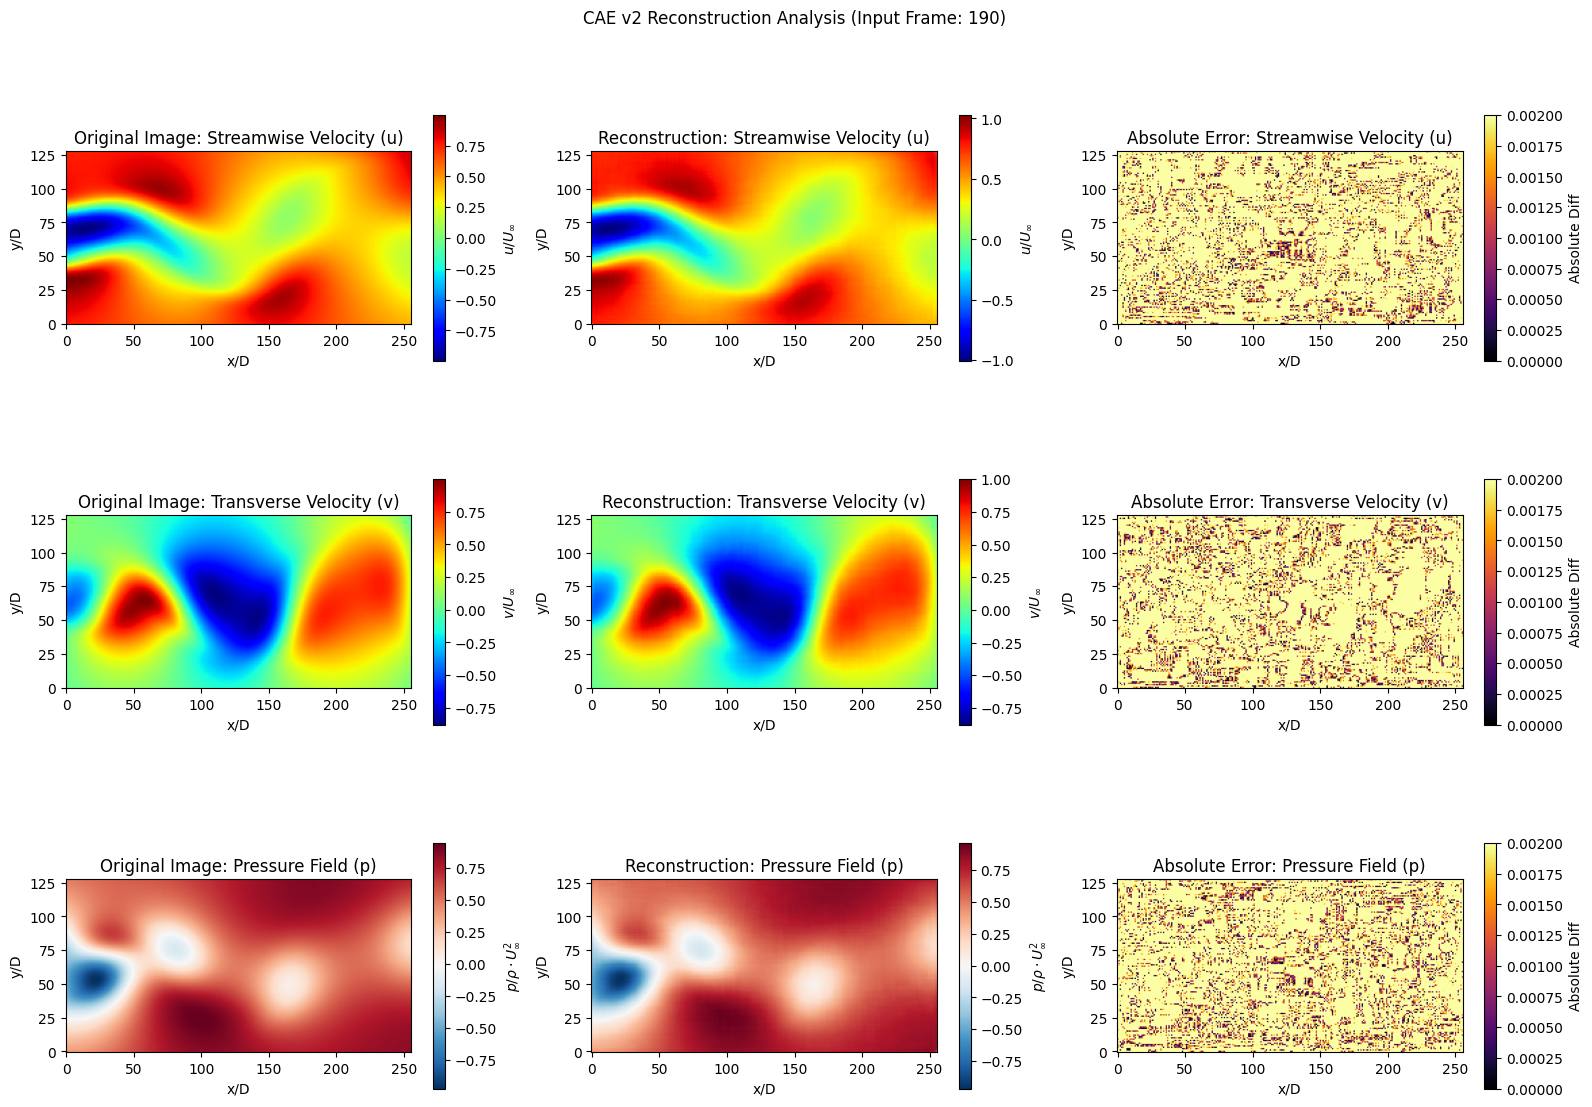

In [51]:
# Channels Comparison

channels = ['Streamwise Velocity (u)', 'Transverse Velocity (v)', 'Pressure Field (p)']
cmaps = ['jet', 'jet', 'RdBu_r']
units = ['$u / U_{\infty}$', '$v / U_{\infty}$', r'$p / \rho \cdot U_{\infty}^2$']

# Grid 3x2 (3 channels, 2 version: original and recontructed)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for i in range(3):
    # Original image
    im1 = axes[i, 0].imshow(original[i], cmap=cmaps[i], origin='lower')
    axes[i, 0].set_title(f"Original Image: {channels[i]}")
    axes[i, 0].set_xlabel("x/D")
    axes[i, 0].set_ylabel("y/D")
    fig.colorbar(im1, ax=axes[i, 0], label=units[i], shrink=0.6)

    # Reconstructed image
    im2 = axes[i, 1].imshow(recontructed[i], cmap=cmaps[i], origin='lower')
    axes[i, 1].set_title(f"Reconstruction: {channels[i]}")
    axes[i, 1].set_xlabel("x/D")
    axes[i, 1].set_ylabel("y/D")
    fig.colorbar(im2, ax=axes[i, 1], label=units[i], shrink=0.6)

    # Absolute Error Map (|Original - Reconstructed|)
    diff = np.abs(original[i] - recontructed[i])
    im3 = axes[i, 2].imshow(diff, cmap='inferno', origin='lower', vmin=0, vmax=0.002)
    axes[i, 2].set_title(f"Absolute Error: {channels[i]}")
    axes[i, 2].set_xlabel("x/D")
    axes[i, 2].set_ylabel("y/D")
    fig.colorbar(im3, ax=axes[i, 2], label="Absolute Diff", shrink=0.6)

plt.suptitle(f"CAE v2 Reconstruction Analysis (Input Frame: {idx})")
plt.tight_layout()
plt.show()

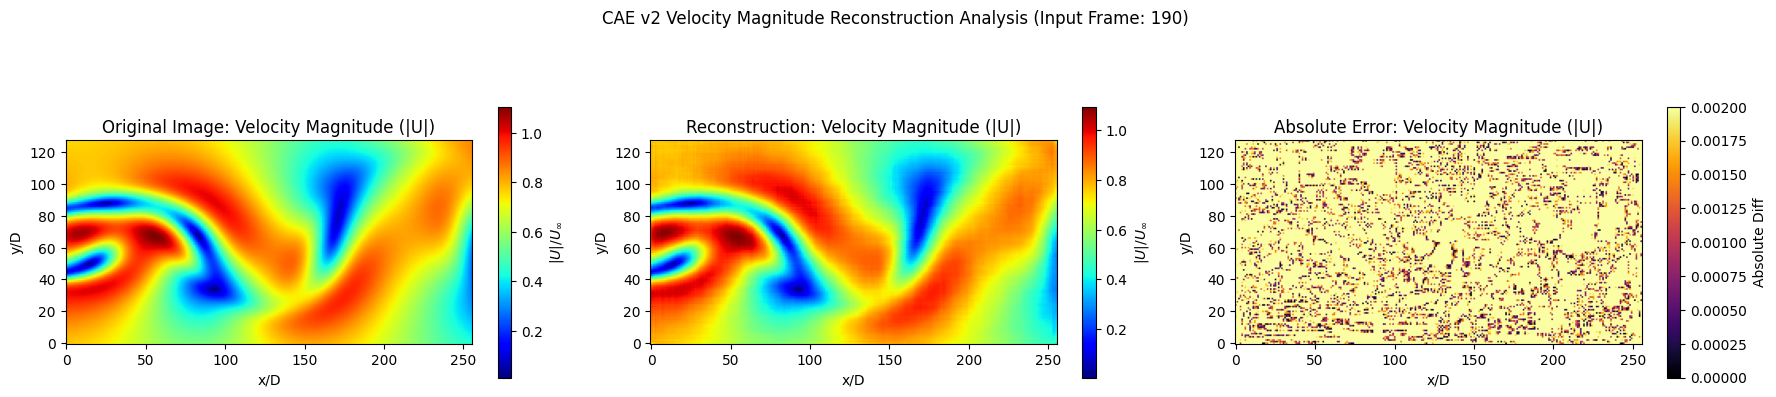

In [52]:
# Magnitude Comparison

u_orig, v_orig = original[0], original[1]
u_rec, v_rec = recontructed[0], recontructed[1]

# Compute velocity magnitude
magnitude_orig = np.sqrt(u_orig**2 + v_orig**2)
magnitude_rec = np.sqrt(u_rec**2 + v_rec**2)
magnitude_diff = np.abs(magnitude_orig - magnitude_rec)

# Grid 1x3 (1 row, 3 columns) for velocity magnitude analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
cmap_mag = "speed" if "speed" in plt.colormaps() else "jet"

# Original image
im1 = axes[0].imshow(magnitude_orig, cmap=cmap_mag, origin="lower")
axes[0].set_title("Original Image: Velocity Magnitude (|U|)")
axes[0].set_xlabel("x/D")
axes[0].set_ylabel("y/D")
fig.colorbar(im1, ax=axes[0], label="$|U| / U_{\infty}$", shrink=0.7)

# Reconstructed image
im2 = axes[1].imshow(magnitude_rec, cmap=cmap_mag, origin="lower")
axes[1].set_title("Reconstruction: Velocity Magnitude (|U|)")
axes[1].set_xlabel("x/D")
axes[1].set_ylabel("y/D")
fig.colorbar(im2, ax=axes[1], label="$|U| / U_{\infty}$", shrink=0.7)

# Absolute Error Map (|Original - Reconstructed|)
im3 = axes[2].imshow(magnitude_diff, cmap="inferno", origin="lower", vmin=0, vmax=0.002)
axes[2].set_title("Absolute Error: Velocity Magnitude (|U|)")
axes[2].set_xlabel("x/D")
axes[2].set_ylabel("y/D")
fig.colorbar(im3, ax=axes[2], label="Absolute Diff", shrink=0.7)

plt.suptitle(
    f"CAE v2 Velocity Magnitude Reconstruction Analysis (Input Frame: {idx})"
)
plt.tight_layout()
plt.show()